In [4]:
#importation des bibliotheques
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [5]:
#ecrire la version de tf et tfds
print("Version de tensorflow:",format(tf.__version__))
print("Version des datasets tensorflow:",tfds.__version__)

Version de tensorflow: 2.20.0
Version des datasets tensorflow: 4.9.10


In [6]:
#Charger le dataset MNIST
(train_data,val_data,test_data),info=tfds.load('mnist',split=['train','test[:50%]','test[50%:]'],as_supervised=True,shuffle_files=True,with_info=True)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.SUIZWR_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.SUIZWR_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [7]:
#Voir la taille du jeu de données
print("Taille du dataset train:",format(len(train_data)))
print("Taille du dataset validation:",format(len(val_data)))
print("Taille du dataset test:",format(len(test_data)))

Taille du dataset train: 60000
Taille du dataset validation: 5000
Taille du dataset test: 5000


In [8]:
#Solution 2 pour voir l taille du jeu de données
info.splits["train"].num_examples

60000

In [9]:
info.splits["test"].num_examples

10000

In [10]:
#Voir le nombre des classes
info.features["label"].num_classes

10

In [11]:
info.features["label"].names

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

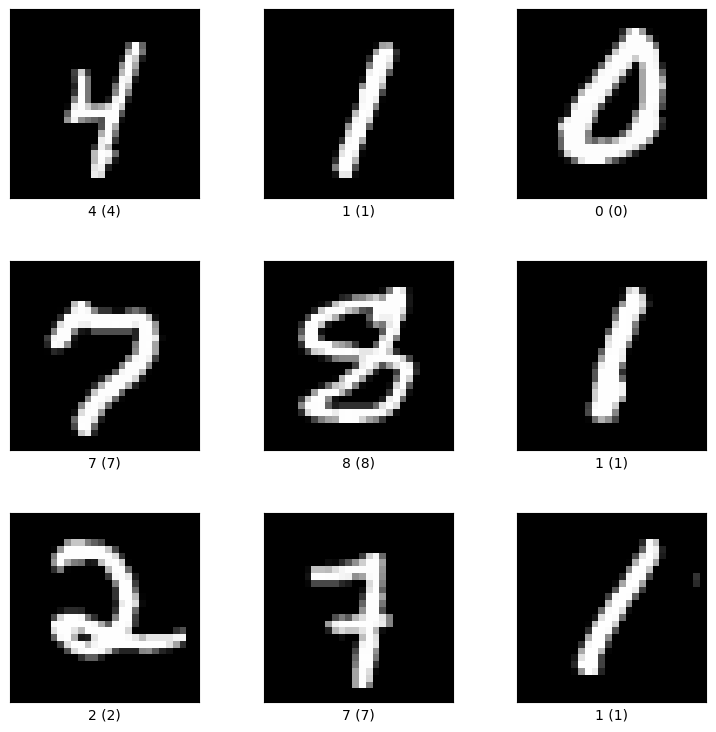

In [12]:
fig=tfds.show_examples(train_data,info)

In [13]:
#Préparation de données n'est pas nécessaire dans ce cas vu qu'on a uniquement deux couleurs qui sont le noir et le blanc donc on a 2 classes
#Les deux classes sont 0 et 1
#Si on est dans le cas du dataset cifar10 ou on a plusieurs couuleurs on doit normaliser les pixels afin de les rendre entre 0 et 1
#def preprocess(image,label):
     #normalized_image=tf.cast(image,tf.float32)/255.0
     #return normalized_image,label



In [14]:
#Preparation des lots de données train
def train_data_prep(data,shuffle_size,batch_size):
  #data=data.map(preprocess) si on a la fonction preprocess
  data=data.cache()
  data=data.shuffle(shuffle_size).repeat()
  data=data.batch(batch_size)
  data=data.prefetch(1)
  return data



In [15]:
#Preparation des lots de données test
def test_data_prep(data,batch_size):
  #data=data.map(preprocess)
  data=data.cache()
  data=data.batch(batch_size)
  data=data.prefetch(1)
  return data

In [16]:
train_data_prepared=train_data_prep(train_data,1000,32)



In [17]:
test_data_prepared=test_data_prep(test_data,32)

In [18]:
val_data_prepared=test_data_prep(val_data,32)

In [19]:
#Creation du modele CNN avec definition de son architecture
#Le jeu de donnees MNIST n'est pas complexe et les images ne contiennent pas beaucoup de details
#donc il suffit de faire une seule convolution afin d'extraire les formes et les lignes et un seul pooling pour reduire la dimension des cartes
import tensorflow as tf
image_size=[28,28,1]
cnn_mnist=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=image_size),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128,activation='relu'),
    tf.keras.layers.Dense(units=64,activation='relu'),
    tf.keras.layers.Dense(units=10,activation='softmax')]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,394,122 (5.32 MB)

 Trainable params: 1,394,122 (5.32 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#compiler le modele c'est a dire configurer le modele avant l'entrainement
cnn_mnist.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
def plot_acc(epochs,acc,val_acc):
  plt.figure(figsize=(10,5))
  plt.plot(epochs,acc,'pink',label="Training accuracy")
  plt.plot(epochs,val_acc,'purple',label="Validation Accuracy")
  plt.title("Validation et Training Accuracy")
  plt.legend(loc=0)
  plt.figure()


In [63]:
def plot_loss(epochs,loss,val_loss):
  plt.figure(figsize=(10,5))
  plt.plot(epochs,loss,'green',label="Training loss")
  plt.plot(epochs,val_loss,'red',label="Validation loss")
  plt.title("Validation et Training Loss")
  plt.legend(loc=0)
  plt.figure()

In [70]:
#Entrainer le modele
batch_size = 32
train_size = info.splits["train"].num_examples

val_size = len(val_data_prepared)


train_steps = int(train_size/batch_size)
val_steps = int(val_size/batch_size)

model_mnist = cnn_mnist.fit(train_data_prepared,
              validation_data=val_data_prepared,
              epochs=9,
              steps_per_epoch=train_steps,
              validation_steps=val_steps)

Epoch 1/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9942 - loss: 0.0196 - val_accuracy: 0.9844 - val_loss: 0.0600
Epoch 2/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9953 - loss: 0.0182 - val_accuracy: 0.9766 - val_loss: 0.1236
Epoch 3/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9956 - loss: 0.0173 - val_accuracy: 0.9766 - val_loss: 0.3017
Epoch 4/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9958 - loss: 0.0160 - val_accuracy: 0.9766 - val_loss: 0.3144
Epoch 5/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9966 - loss: 0.0120 - val_accuracy: 0.9766 - val_loss: 0.2211
Epoch 6/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9963 - loss: 0.0150 - val_accuracy: 0.9609 - val_loss: 0.3559
Epoch 7/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9973 - loss: 0.0116 - val_accuracy: 0.9531 - val_loss: 0.5010
Epoch 8/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9967 - loss: 0

<Axes: >

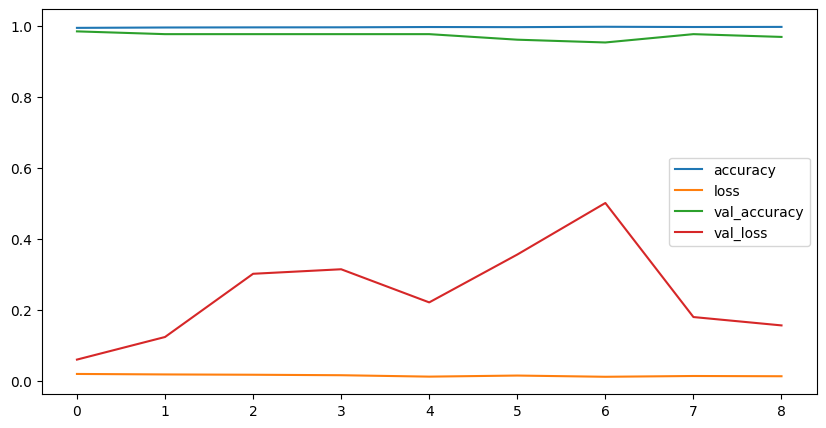

In [71]:
#Visualiser le modele
import pandas as pd
model_mnist=model_mnist.history
loss_acc_df=pd.DataFrame(model_mnist)
loss_acc_df.plot(figsize=(10,5))


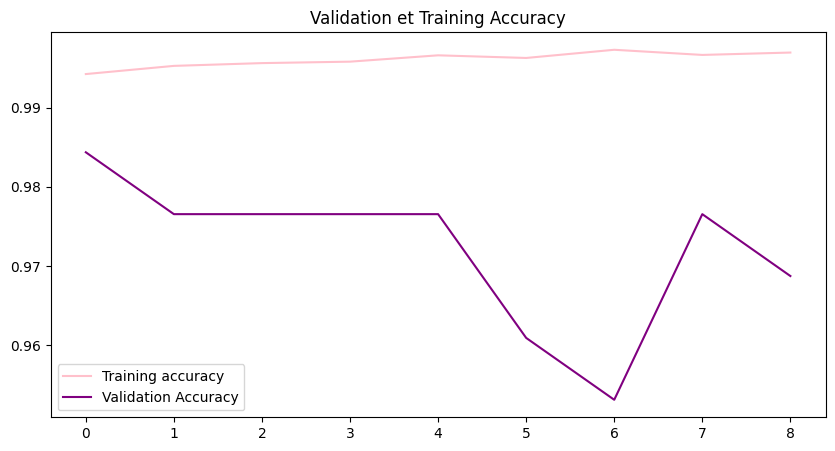

<Figure size 640x480 with 0 Axes>

In [72]:

acc=model_mnist['accuracy']
val_acc=model_mnist["val_accuracy"]
loss=model_mnist["loss"]
loss_val=model_mnist["val_loss"]
# Génère automatiquement la liste des époques (ex: [0, 1, 2, 3, 4, 5, 6, 7, 8])
epochs = range(len(loss))
plot_acc(epochs,acc,val_acc)




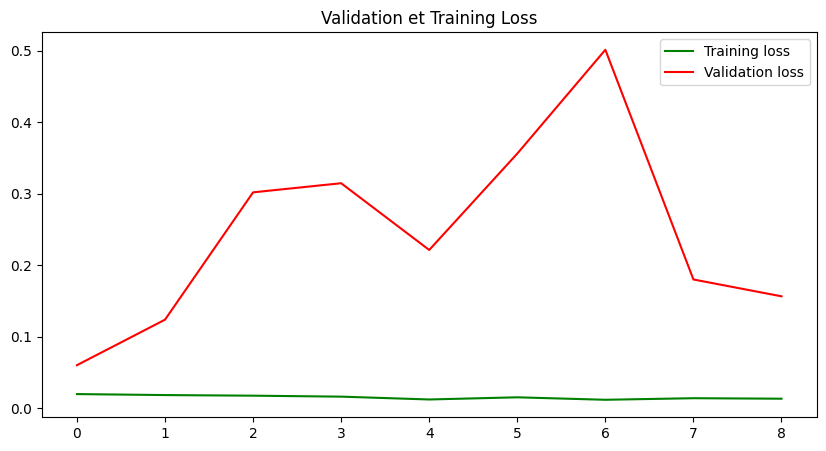

<Figure size 640x480 with 0 Axes>

In [73]:
plot_loss(epochs,loss,loss_val)

In [27]:
#Phase d'amelioration du modele
import tensorflow_datasets as tfds
(train_data_2,val_data_2,test_data_2),info=tfds.load(
    'mnist',
    split=['train','test[:50%]','test[50%:]'],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

In [42]:
#La construction de l'architecture du modele CNN
import tensorflow as tf
input_shape=[28,28,1]
mnist_cnn_2=tf.keras.models.Sequential(
    [

    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=input_shape),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    #Gestion de couches
    tf.keras.layers.Dense(units=64,activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(units=10,activation='softmax')


]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
train_data_prepared_2=train_data_prep(train_data_2,1000,32)


In [44]:
val_data_prepared_2=test_data_prep(val_data_2,32)

In [45]:
test_data_prepared_2=test_data_prep(test_data_2,32)

In [46]:
#compiler le modele
mnist_cnn_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [53]:
#Entrainement du deuxieme modele
batch_size=32
train_size=info.splits["train"].num_examples
val_size=len(val_data_prepared_2)
train_steps=int(train_size/batch_size)
val_steps=int(val_size/batch_size)
model_mnist_2=mnist_cnn_2.fit(
    train_data_prepared_2,
    validation_data=val_data_prepared_2,
    epochs=10,
    steps_per_epoch=train_steps,
    validation_steps=val_steps
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9844 - val_loss: 0.0704
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9766 - val_loss: 0.0875
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9904 - loss: 0.0298 - val_accuracy: 0.9844 - val_loss: 0.0429
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9913 - loss: 0.0271 - val_accuracy: 0.9766 - val_loss: 0.0464
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9766 - val_loss: 0.0787
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9926 - loss: 0.0207 - val_accuracy: 0.9766 - val_loss: 0.0820
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9934 - loss: 0.0192 - val_accuracy: 0.9844 - val_loss: 0.0819
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9937 -

<Axes: >

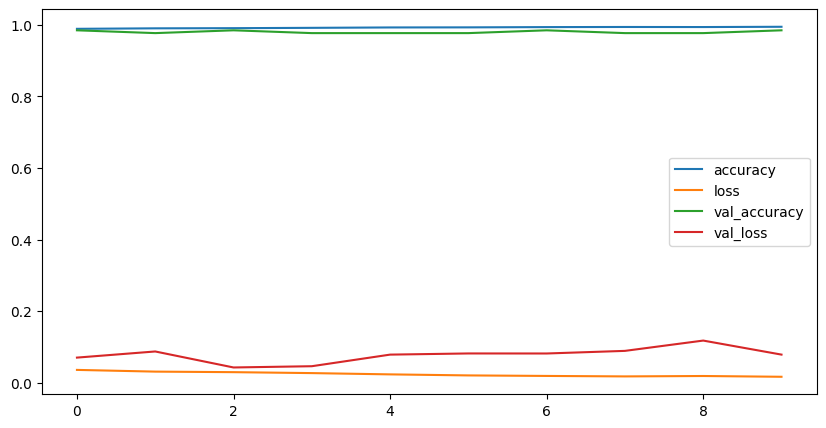

In [57]:
import pandas as pd
model_history_2=model_mnist_2.history
loss_acc_df_2=pd.DataFrame(model_history_2)
loss_acc_df_2.plot(figsize=(10,5))

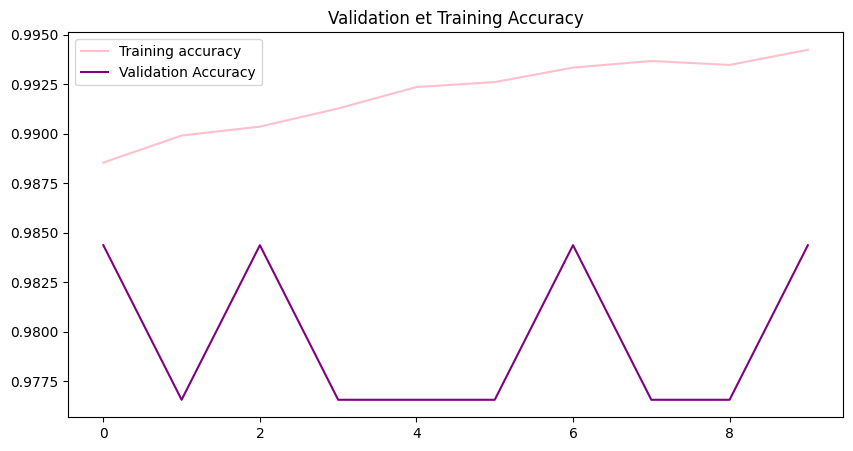

<Figure size 640x480 with 0 Axes>

In [65]:
acc_2=model_history_2["accuracy"]
val_loss_2=model_history_2["val_loss"]
val_accuracy_2=model_history_2["val_accuracy"]
loss_2=model_history_2["loss"]
epochs_2=range(len(loss_2))
plot_acc(epochs_2,acc_2,val_accuracy_2)


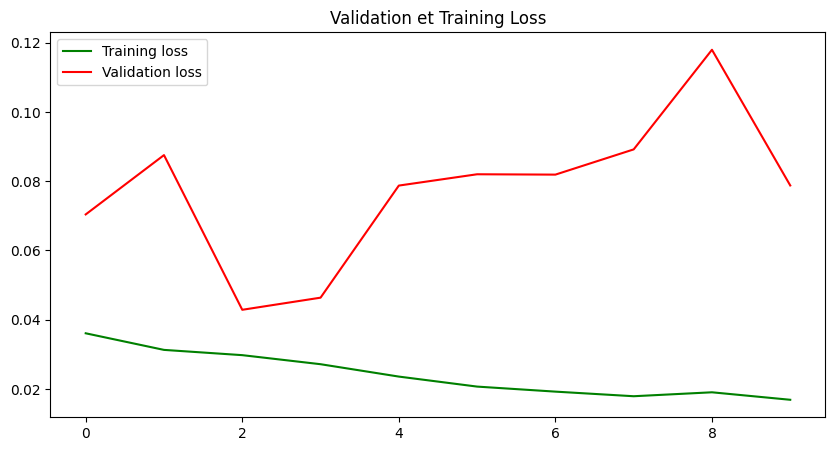

<Figure size 640x480 with 0 Axes>

In [66]:
plot_loss(epochs_2,loss_2,val_loss_2)

In [77]:
mnist_cnn_2.save('MNIST.h5')